In [1]:
import sys, json
from pathlib import Path

import numpy as np
import torch
import SimpleITK as sitk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import yaml
from rich import print as rprint

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

with open(ROOT / "config.yaml") as f:
    cfg = yaml.safe_load(f)

SPLITS_DIR   = ROOT / cfg["paths"]["splits"]
MODELS_DIR   = ROOT / cfg["paths"]["models"]
GRAPHS_DIR   = ROOT / cfg["paths"]["graphs"]
PRED_DIR     = ROOT / cfg["paths"]["predictions"]
VIEWER_DIR   = ROOT / cfg["paths"]["viewer_exports"]
PROC_IMGS    = ROOT / cfg["paths"]["processed_imgs"]
PROC_LBLS    = ROOT / cfg["paths"]["processed_lbl"]

for d in [PRED_DIR, VIEWER_DIR, GRAPHS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
rprint(f"[bold green]Config loaded.[/] Device: [cyan]{device}[/]")

Config loaded. Device: cuda

In [2]:
from src.model import build_model
from src.utils import load_label_mapping

with open(SPLITS_DIR / "label_mapping.json") as f:
    mapping = json.load(f)

LABEL_TO_IDX = {int(k): int(v) for k, v in mapping["label_to_idx"].items()}
IDX_TO_LABEL = {int(k): int(v) for k, v in mapping["idx_to_label"].items()}
NUM_CLASSES  = mapping["num_classes"]

# FDI label names for display
FDI_NAMES = {
    0: "background", 1: "upper jaw", 2: "lower jaw",
    3: "UR8", 4: "UR7", 5: "UR6", 6: "UR5", 7: "UR4",
    8: "UR3", 9: "UR2", 10: "UR1",
    11: "UL1", 12: "UL2", 13: "UL3", 14: "UL4",
    15: "UL5", 16: "UL6", 17: "UL7", 18: "UL8",
    21: "LL8", 22: "LL7", 23: "LL6", 24: "LL5",
    25: "LL4", 26: "LL3", 27: "LL2", 28: "LL1",
    31: "LR1", 32: "LR2", 33: "LR3", 34: "LR4",
    35: "LR5", 36: "LR6", 37: "LR7", 38: "LR8",
    41: "LL8b", 42: "LL7b", 43: "LL6b", 44: "LL5b",
    45: "LL4b", 46: "LL3b", 47: "LL2b", 48: "LL1b",
}

patch_size = cfg["training"]["patch_size"]
model_name = cfg["training"]["model"]

model = build_model(model_name, NUM_CLASSES, patch_size)
ckpt  = torch.load(MODELS_DIR / "best.pth", map_location=device)
model.load_state_dict(ckpt["model"])
model = model.to(device).eval()

rprint(f"[bold green]Model loaded.[/] Epoch={ckpt['epoch']} | "
       f"Best Val Dice={ckpt['best_dice']:.4f}")
rprint(f"Num classes: {NUM_CLASSES}")

<frozen importlib._bootstrap_external>:1241: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


Model loaded. Epoch=70 | Best Val Dice=0.3342

Num classes: 43

In [3]:
with open(SPLITS_DIR / "test.json") as f:
    test_manifest = json.load(f)

# pick first test case
case     = test_manifest[0]
case_id  = case["case_id"]
img_path = case["image"]
lbl_path = case["label"]

rprint(f"Running inference on: [cyan]{case_id}[/]")

img_sitk = sitk.ReadImage(img_path)
lbl_sitk = sitk.ReadImage(lbl_path)

img_arr = sitk.GetArrayFromImage(img_sitk).astype(np.float32)  # Z,Y,X
lbl_arr = sitk.GetArrayFromImage(lbl_sitk).astype(np.int32)

print(f"Image shape : {img_arr.shape}  range=[{img_arr.min():.2f}, {img_arr.max():.2f}]")
print(f"Label shape : {lbl_arr.shape}  unique={np.unique(lbl_arr).tolist()[:10]}...")

Running inference on: ToothFairy2P_011

Image shape : (170, 279, 370)  range=[-1.00, 1.00]
Label shape : (170, 279, 370)  unique=[0, 1, 3, 4, 7, 27, 28, 29, 30, 31]...


In [4]:
from monai.inferers import sliding_window_inference

# prepare tensor: (1, 1, Z, Y, X)
img_tensor = torch.from_numpy(img_arr).unsqueeze(0).unsqueeze(0).to(device)

with torch.no_grad():
    logits = sliding_window_inference(
        inputs=img_tensor,
        roi_size=tuple(patch_size),
        sw_batch_size=1,
        predictor=model,
        overlap=0.5,
        mode="gaussian",
        sw_device=device,
        device="cpu",        # accumulate output on CPU - avoids OOM
    )

# argmax to get predicted class per voxel
pred_arr = logits.squeeze(0).argmax(dim=0).numpy().astype(np.uint8)  # Z,Y,X
print(f"Prediction shape : {pred_arr.shape}")
print(f"Predicted classes: {np.unique(pred_arr).tolist()}")

# remap back to raw FDI label IDs for saving
pred_fdi = np.zeros_like(pred_arr, dtype=np.uint8)
for idx, raw in IDX_TO_LABEL.items():
    pred_fdi[pred_arr == idx] = raw

print(f"FDI label IDs in prediction: {np.unique(pred_fdi).tolist()}")

Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)


Prediction shape : (170, 279, 370)
Predicted classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26, 27, 28, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 41, 42]
FDI label IDs in prediction: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 26, 27, 28, 31, 32, 33, 34, 35, 37, 38, 41, 42, 43, 44, 45, 47, 48]


In [5]:
def arr_to_sitk(arr, ref_sitk):
    out = sitk.GetImageFromArray(arr)
    out.SetSpacing(ref_sitk.GetSpacing())
    out.SetOrigin(ref_sitk.GetOrigin())
    out.SetDirection(ref_sitk.GetDirection())
    return out

# save raw index prediction
pred_sitk = arr_to_sitk(pred_arr, img_sitk)
sitk.WriteImage(sitk.Cast(pred_sitk, sitk.sitkUInt8),
                str(PRED_DIR / f"{case_id}_pred.mha"), useCompression=True)

# save FDI-remapped prediction
pred_fdi_sitk = arr_to_sitk(pred_fdi, img_sitk)
sitk.WriteImage(sitk.Cast(pred_fdi_sitk, sitk.sitkUInt8),
                str(PRED_DIR / f"{case_id}_pred_fdi.mha"), useCompression=True)

# export for viewer: scan.nii.gz + mask.nii.gz
sitk.WriteImage(img_sitk,      str(VIEWER_DIR / "scan.nii.gz"),  useCompression=True)
sitk.WriteImage(pred_fdi_sitk, str(VIEWER_DIR / "mask.nii.gz"),  useCompression=True)

rprint(f"[green]Saved predictions to {PRED_DIR}[/]")
rprint(f"[green]Saved viewer exports to {VIEWER_DIR}[/]")

Saved predictions to /home/saber/internships/assignments/cbct/results/predictions

Saved viewer exports to /home/saber/internships/assignments/cbct/viewer/exports

The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


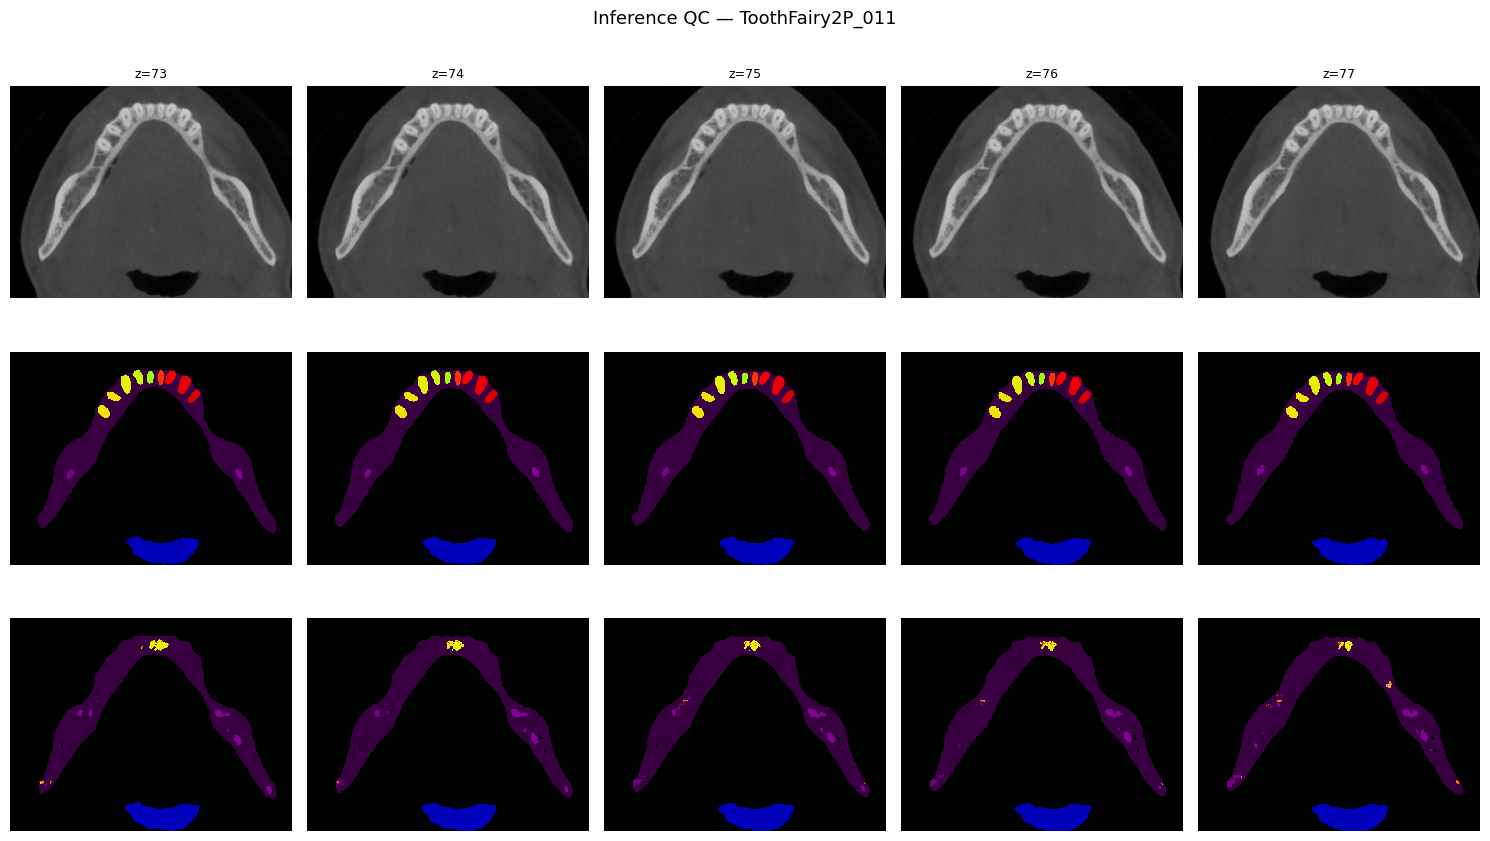

In [6]:
def show_comparison(img, gt, pred, case_id, n_slices=5, save=True):
    # find slices with most tooth labels
    tooth_counts = [(lbl_arr[z] > 1).sum() for z in range(img.shape[0])]
    top_z = sorted(range(len(tooth_counts)),
                   key=lambda z: tooth_counts[z], reverse=True)[:n_slices]
    top_z = sorted(top_z)

    fig, axes = plt.subplots(3, n_slices, figsize=(n_slices * 3, 9))
    fig.suptitle(f"Inference QC — {case_id}", fontsize=13)
    cmap_lbl = plt.cm.get_cmap("nipy_spectral", NUM_CLASSES)

    for col, zi in enumerate(top_z):
        # image
        axes[0, col].imshow(img[zi], cmap="gray", vmin=-1, vmax=1)
        axes[0, col].set_title(f"z={zi}", fontsize=9)
        axes[0, col].axis("off")

        # ground truth
        axes[1, col].imshow(gt[zi], cmap=cmap_lbl, vmin=0, vmax=NUM_CLASSES,
                            interpolation="none")
        axes[1, col].axis("off")

        # prediction
        axes[2, col].imshow(pred[zi], cmap=cmap_lbl, vmin=0, vmax=NUM_CLASSES,
                            interpolation="none")
        axes[2, col].axis("off")

    axes[0, 0].set_ylabel("Image",      fontsize=10, labelpad=4)
    axes[1, 0].set_ylabel("Ground Truth", fontsize=10, labelpad=4)
    axes[2, 0].set_ylabel("Prediction", fontsize=10, labelpad=4)
    plt.tight_layout()
    if save:
        plt.savefig(GRAPHS_DIR / f"inference_qc_{case_id}.png", dpi=130)
    plt.show()

show_comparison(img_arr, lbl_arr, pred_arr, case_id)

In [8]:
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.utils.enums import MetricReduction

post_pred  = AsDiscrete(to_onehot=NUM_CLASSES)
post_label = AsDiscrete(to_onehot=NUM_CLASSES)

dice_metric = DiceMetric(
    include_background=False,
    reduction=MetricReduction.MEAN_BATCH,
    get_not_nans=True,
)

pred_t  = torch.from_numpy(pred_arr).long()
label_t = torch.from_numpy(lbl_arr).long()

# one-hot on CPU
pred_oh  = post_pred(pred_t.unsqueeze(0))
label_oh = post_label(label_t.unsqueeze(0))

dice_metric(y_pred=[pred_oh], y=[label_oh])
result, not_nans = dice_metric.aggregate()
dice_metric.reset()

# build results table
rows = []
for i in range(len(result)):
    if not_nans[i]:
        raw_lbl = IDX_TO_LABEL.get(i + 1, i + 1)
        name    = FDI_NAMES.get(raw_lbl, f"tooth_{raw_lbl}")
        rows.append({"idx": i+1, "fdi": raw_lbl,
                     "name": name, "dice": result[i].item()})

import pandas as pd
df_dice = pd.DataFrame(rows).sort_values("dice", ascending=False)
print(f"\nMean Dice (this case): {df_dice['dice'].mean():.4f}")
print(f"Best  class: {df_dice.iloc[0]['name']} = {df_dice.iloc[0]['dice']:.4f}")
print(f"Worst class: {df_dice.iloc[-1]['name']} = {df_dice.iloc[-1]['dice']:.4f}")
df_dice


Mean Dice (this case): 0.1803
Best  class: UR4 = 0.9619
Worst class: LL5b = 0.0000


,idx,fdi,name,dice
3,7,7,UR4,0.961877
0,1,1,upper jaw,0.905868
2,4,4,UR7,0.244481
6,29,33,LR3,0.076848
11,37,43,LL6b,0.067950
7,30,34,LR4,0.052808
5,28,32,LR2,0.023790
1,3,3,UR8,0.008522
10,36,42,LL7b,0.002009
4,27,31,LR1,0.000000


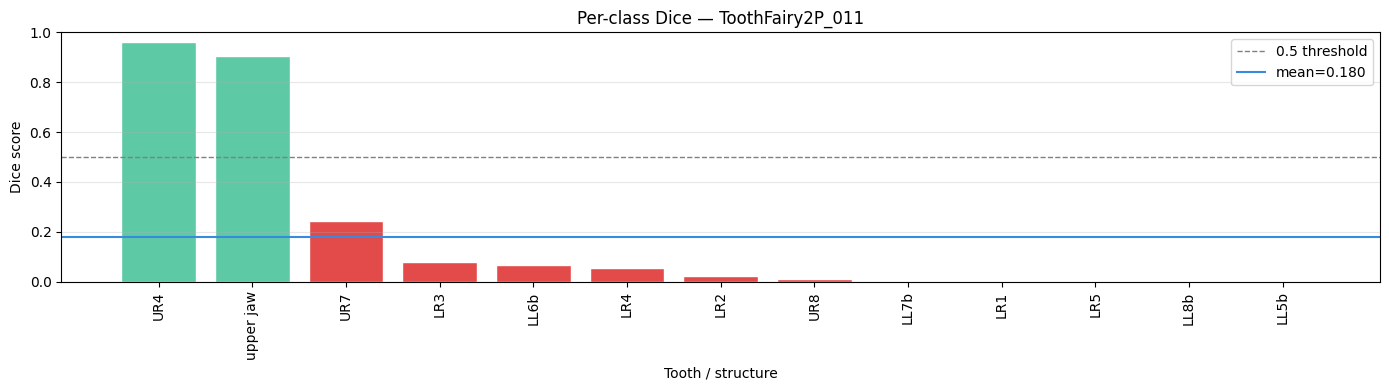

In [9]:
fig, ax = plt.subplots(figsize=(14, 4))
colors = ["#5DCAA5" if d >= 0.5 else "#EF9F27" if d >= 0.3 else "#E24B4A"
          for d in df_dice["dice"]]
ax.bar(df_dice["name"], df_dice["dice"], color=colors, edgecolor="white")
ax.axhline(0.5, color="gray", lw=1, linestyle="--", label="0.5 threshold")
ax.axhline(df_dice["dice"].mean(), color="#378ADD", lw=1.5,
           linestyle="-", label=f"mean={df_dice['dice'].mean():.3f}")
ax.set_xlabel("Tooth / structure")
ax.set_ylabel("Dice score")
ax.set_title(f"Per-class Dice — {case_id}")
ax.set_ylim(0, 1)
ax.tick_params(axis="x", rotation=90)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(GRAPHS_DIR / f"per_class_dice_{case_id}.png", dpi=150)
plt.show()

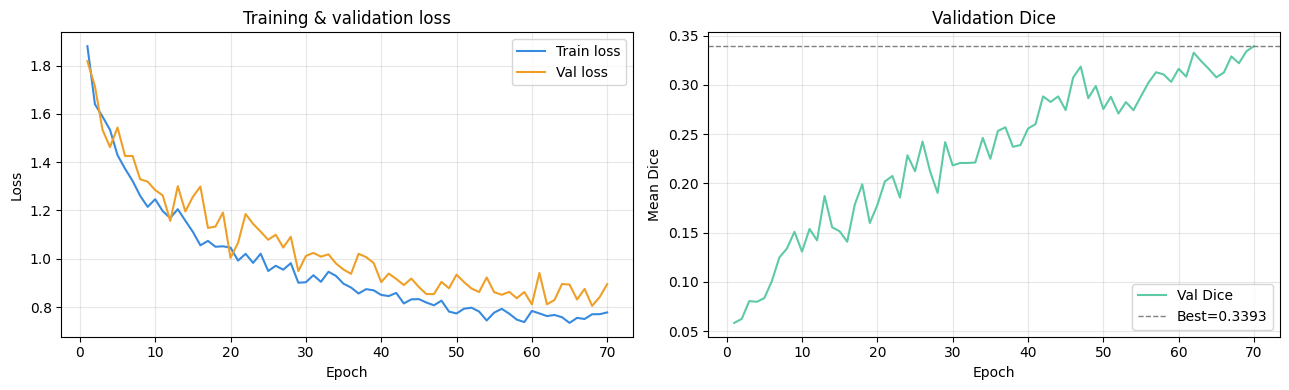

Best Val Dice: 0.3393 at epoch 70

In [10]:
with open(MODELS_DIR / "history.json") as f:
    history = json.load(f)

epochs     = range(1, len(history["train_loss"]) + 1)
train_loss = history["train_loss"]
val_loss   = history.get("val_loss", [])
val_dice   = history["val_dice"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(epochs, train_loss, color="#378ADD", label="Train loss")
if val_loss:
    ax1.plot(epochs, val_loss, color="#EF9F27", label="Val loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Training & validation loss")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs, val_dice, color="#5DCAA5", label="Val Dice")
ax2.axhline(max(val_dice), color="gray", lw=1, linestyle="--",
            label=f"Best={max(val_dice):.4f}")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Mean Dice")
ax2.set_title("Validation Dice")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(GRAPHS_DIR / "training_curves.png", dpi=150)
plt.show()

rprint(f"Best Val Dice: [bold]{max(val_dice):.4f}[/] at epoch {val_dice.index(max(val_dice))+1}")

In [11]:
from rich.table import Table
from rich.console import Console

console = Console()
console.rule("[bold]Inference Summary")
rprint(f"Case ID         : [cyan]{case_id}[/]")
rprint(f"Model           : {model_name} ({ckpt['epoch']} epochs)")
rprint(f"Best Val Dice   : {ckpt['best_dice']:.4f}")
rprint(f"This case Dice  : {df_dice['dice'].mean():.4f}")
rprint(f"Predicted labels: {np.unique(pred_fdi).tolist()}")
rprint(f"\nOutputs:")
rprint(f"  Prediction (.mha)  → [cyan]{PRED_DIR}/{case_id}_pred_fdi.mha[/]")
rprint(f"  Viewer scan        → [cyan]{VIEWER_DIR}/scan.nii.gz[/]")
rprint(f"  Viewer mask        → [cyan]{VIEWER_DIR}/mask.nii.gz[/]")
rprint(f"  Training curves    → [cyan]{GRAPHS_DIR}/training_curves.png[/]")
rprint(f"  QC slices          → [cyan]{GRAPHS_DIR}/inference_qc_{case_id}.png[/]")

──────────────────────────────────────────────── Inference Summary ────────────────────────────────────────────────

Case ID         : ToothFairy2P_011

Model           : nnunet (70 epochs)

Best Val Dice   : 0.3342

This case Dice  : 0.1803

...

Prediction (.mha)  → /home/saber/internships/assignments/cbct/results/predictions/ToothFairy2P_011_pred_fdi.mha

Viewer scan        → /home/saber/internships/assignments/cbct/viewer/exports/scan.nii.gz

Viewer mask        → /home/saber/internships/assignments/cbct/viewer/exports/mask.nii.gz

Training curves    → /home/saber/internships/assignments/cbct/results/graphs/training_curves.png

QC slices          → /home/saber/internships/assignments/cbct/results/graphs/inference_qc_ToothFairy2P_011.png

In [12]:
import struct, gzip, numpy as np
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
viewer_dir = ROOT / "viewer/exports"

for fname in ["scan.nii.gz", "mask.nii.gz"]:
    fpath = viewer_dir / fname
    with gzip.open(fpath, 'rb') as f:
        raw = f.read()
    
    # NIfTI-1 header fields
    sizeof_hdr = struct.unpack_from('<i', raw, 0)[0]
    datatype   = struct.unpack_from('<h', raw, 70)[0]
    ndim       = struct.unpack_from('<h', raw, 40)[0]
    dims       = struct.unpack_from('<8h', raw, 40)
    pixdims    = struct.unpack_from('<8f', raw, 76)
    vox_offset = struct.unpack_from('<f', raw, 108)[0]
    scl_slope  = struct.unpack_from('<f', raw, 112)[0]
    scl_inter  = struct.unpack_from('<f', raw, 116)[0]
    magic      = raw[344:348].decode('ascii', errors='replace')
    
    print(f"\n{'='*50}")
    print(f"File      : {fname}")
    print(f"Raw size  : {len(raw)} bytes")
    print(f"sizeof_hdr: {sizeof_hdr}")
    print(f"magic     : {magic!r}")
    print(f"datatype  : {datatype}")
    print(f"ndim      : {ndim}")
    print(f"dims      : {dims[:ndim+1]}")
    print(f"pixdims   : {[f'{v:.4f}' for v in pixdims[1:4]]}")
    print(f"vox_offset: {vox_offset}")
    print(f"scl_slope : {scl_slope}")
    print(f"scl_inter : {scl_inter}")
    
    # figure out actual data start
    actual_offset = int(max(352, vox_offset))
    n_vox = dims[1] * dims[2] * (dims[3] if ndim >= 3 else 1)
    data_bytes = len(raw) - actual_offset
    print(f"actual_offset: {actual_offset}")
    print(f"n_vox     : {n_vox}")
    print(f"data_bytes: {data_bytes}")
    print(f"bytes/vox : {data_bytes / n_vox:.2f}")
    
    # sample values
    import numpy as np
    dtype_map = {2: np.uint8, 4: np.int16, 8: np.int32, 16: np.float32, 512: np.uint16, 256: np.int8}
    dt = dtype_map.get(datatype, np.int16)
    arr = np.frombuffer(raw[actual_offset:], dtype=dt)[:n_vox]
    print(f"dtype     : {dt}")
    print(f"arr shape : {arr.shape}")
    print(f"val range : [{arr.min()}, {arr.max()}]")
    print(f"unique[:10]: {np.unique(arr)[:10].tolist()}")


File      : scan.nii.gz
Raw size  : 70196752 bytes
sizeof_hdr: 348
magic     : 'n+1\x00'
datatype  : 16
ndim      : 3
dims      : (3, 370, 279, 170)
pixdims   : ['0.3000', '0.3000', '0.3000']
vox_offset: 352.0
scl_slope : 1.0
scl_inter : 0.0
actual_offset: 352
n_vox     : 17549100
data_bytes: 70196400
bytes/vox : 4.00
dtype     : <class 'numpy.float32'>
arr shape : (17549100,)
val range : [-1.0, 1.0]
unique[:10]: [-1.0, -0.9994998574256897, -0.9989997744560242, -0.9984996318817139, -0.9979994893074036, -0.997499406337738, -0.9969993233680725, -0.9964991807937622, -0.9959990382194519, -0.9954989552497864]

File      : mask.nii.gz
Raw size  : 17549452 bytes
sizeof_hdr: 348
magic     : 'n+1\x00'
datatype  : 2
ndim      : 3
dims      : (3, 370, 279, 170)
pixdims   : ['0.3000', '0.3000', '0.3000']
vox_offset: 352.0
scl_slope : 1.0
scl_inter : 0.0
actual_offset: 352
n_vox     : 17549100
data_bytes: 17549100
bytes/vox : 1.00
dtype     : <class 'numpy.uint8'>
arr shape : (17549100,)
val range